### Simulated Annealing (Tavlama Benzetimi) Algoritması

## 1. Problemin Tanımı
Bir önceki deneyde (Hill Climbing), algoritmamızın **Yerel Optimum (Local Optima)** tuzağına düştüğünü gördük.
- **Mevcut Durum:** Algoritma 300°C'deki küçük tepeye çıkıyor ve orada sıkışıyor.
- **Hedef:** 300°C'deki yerel optimumu göze alıp geçerek, 500°C'deki **Global Optimum** noktasına ulaşmak.

## 2. Neden Simulated Annealing?
Hill Climbing "Asla daha kötüye gitme" prensibiyle çalışır. Simulated Annealing ise metalurjideki tavlama işleminden esinlenerek:
1. **Yüksek Sıcaklıkta:** Kötü hamleleri kabul etme ihtimali yüksektir (Keşif/Exploration).
2. **Düşük Sıcaklıkta:** Sadece iyi hamleleri kabul eder (Sömürü/Exploitation).

Bu özellik sayesinde algoritma, yerel zirvelerden "aşağı inerek" kurtulabilir.

In [12]:
import random
import math
import matplotlib.pyplot as plt

### Parametreler

In [2]:
temp = 100

In [3]:
T = 1000

In [4]:
cooling_rate = 0.98

In [5]:
min_T = 0.01

In [6]:
def calculateHardness(temp):
    if temp < 400:
        return -1 * (temp - 300)**2 + 5000
    else:
        return -1 * (temp - 500)**2 + 10000

In [7]:
def boltzmann(T, neighbor, current):
    delta = current - neighbor
    return math.exp(- delta / T)

In [8]:
history_temp = []
history_score = []

In [11]:
while(min_T < T):
    current_score = calculateHardness(temp)
    neighbor_temp = temp + random.randint(-110, 110)
    neighbor_score = calculateHardness(neighbor_temp)
    if(neighbor_score > current_score):
        temp = neighbor_temp
    else:
        p = boltzmann(T, neighbor_score, current_score)
        posibilty = random.random()
        if(posibilty < p):
            temp = neighbor_temp
    history_temp.append(temp)
    history_score.append(current_score)
    T = T * cooling_rate

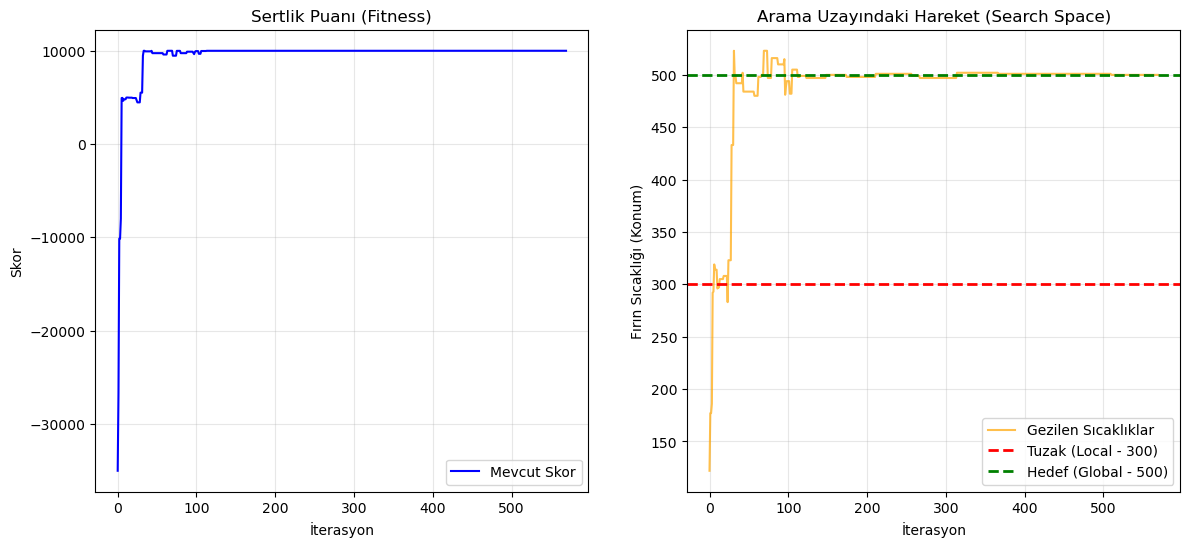

In [14]:


plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history_score, color='blue', label='Mevcut Skor')
plt.title("Sertlik Puanı (Fitness)")
plt.xlabel("İterasyon")
plt.ylabel("Skor")
plt.grid(True, alpha=0.3)
plt.legend()

# GRAFİK 2: Arama uzayındaki hareketler
plt.subplot(1, 2, 2)
plt.plot(history_temp, color='orange', alpha=0.7, label='Gezilen Sıcaklıklar')

# Referans Çizgileri
plt.axhline(y=300, color='red', linestyle='--', linewidth=2, label='Tuzak (Local - 300)')
plt.axhline(y=500, color='green', linestyle='--', linewidth=2, label='Hedef (Global - 500)')

plt.title("Arama Uzayındaki Hareket (Search Space)")
plt.xlabel("İterasyon")
plt.ylabel("Fırın Sıcaklığı (Konum)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()